# Breast Cancer Classification (CNN)

### 1. Import Libraries

In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import load_img, img_to_array

### 2. Dataset Path

In [35]:
dataset_path =  r"C:\Users\madus\Downloads\archive\IDC_regular_ps50_idx5\12876"

### 3.Load Images and Labels

In [36]:
!pip install pillow numpy tqdm
!pip install tensorflow


In [37]:
import os
from tqdm import tqdm

In [38]:
import os
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

def load_data(folder_path, label):
    images = []
    labels = []
    for file in os.listdir(folder_path):
        try:
            img_path = os.path.join(folder_path, file)
            img = load_img(img_path, target_size=(50, 50))   # resize to 50x50
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(label)
        except Exception as e:
            print(f"Error loading image {file}: {e}")
    return images, labels

dataset_path = r"C:\Users\madus\Downloads\IDC\IDC_regular"

benign_path = os.path.join(dataset_path, "0")       # 0 = benign
malignant_path = os.path.join(dataset_path, "1")    # 1 = malignant

benign_images, benign_labels = load_data(benign_path, 0)
malignant_images, malignant_labels = load_data(malignant_path, 1)

X = np.array(benign_images + malignant_images)
y = np.array(benign_labels + malignant_labels)

print("Dataset Shape:", X.shape, y.shape)


Dataset Shape: (646, 50, 50, 3) (646,)


### 4.Train/Test Split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)

Training samples: (516, 50, 50, 3)
Test samples: (130, 50, 50, 3)


### 5.Build CNN Model (CancerNet)

In [40]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2,2)),
    Dropout(0.25),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.summary()


C:\Users\madus\anaconda3\envs\demo\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### 6.Compile Model

In [41]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### 7.Train Model

In [42]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.8101 - loss: 21.1596 - val_accuracy: 0.9154 - val_loss: 0.2671
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.8934 - loss: 0.8326 - val_accuracy: 0.9154 - val_loss: 0.5320
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.9070 - loss: 0.3074 - val_accuracy: 0.9154 - val_loss: 0.5004
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.9109 - loss: 0.3457 - val_accuracy: 0.9154 - val_loss: 0.4709
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.9128 - loss: 0.3098 - val_accuracy: 0.9154 - val_loss: 0.4031
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.9128 - loss: 0.3165 - val_accuracy: 0.9154 - val_loss: 0.4534
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.9128 - loss: 0.2893 - val_accuracy: 0.9154 - val_loss: 0.3278
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.9128 - loss: 0.2844 - val_accuracy: 0.9154

### 8.Evaluate Model

In [43]:
# Accuracy
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print(classification_report(y_test, y_pred, target_names=["Benign","Malignant"]))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step
Accuracy: 0.9153846153846154
Confusion Matrix:
 [[119   0]
 [ 11   0]]
              precision    recall  f1-score   support

      Benign       0.92      1.00      0.96       119
   Malignant       0.00      0.00      0.00        11

    accuracy                           0.92       130
   macro avg       0.46      0.50      0.48       130
weighted avg       0.84      0.92      0.87       130



C:\Users\madus\anaconda3\envs\demo\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\madus\anaconda3\envs\demo\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\madus\anaconda3\envs\demo\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

### 9. Plot Accuracy & Loss

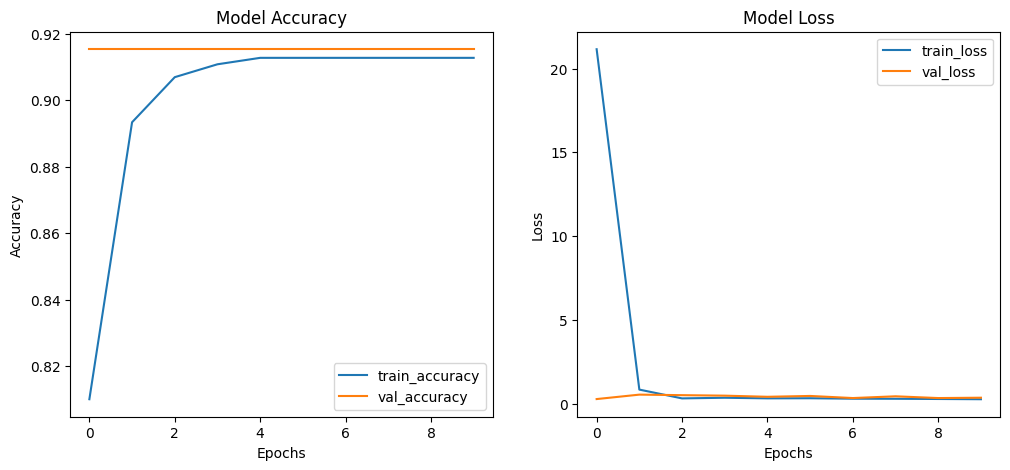

In [44]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

### 10.Save Model

In [45]:
model.save('CancerNet.h5')
print("Model saved as CancerNet.h5")

Model saved as CancerNet.h5
